### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [213]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [214]:
data = pd.read_csv('data/coupons.csv')

In [215]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [216]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

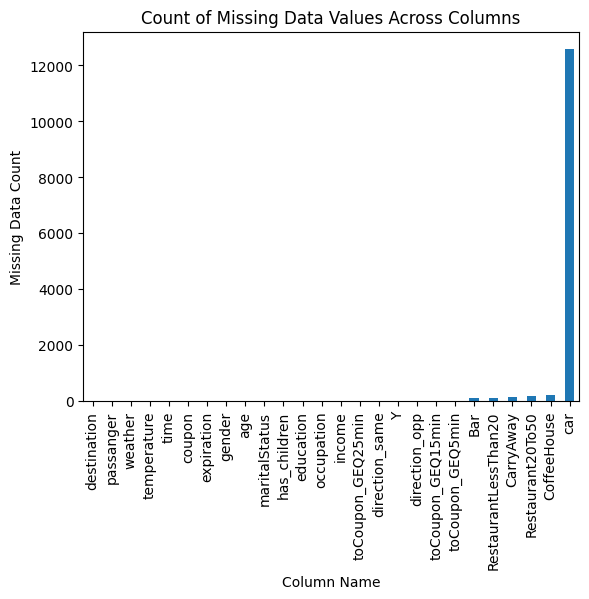

In [221]:
# Create barplot using matplotlib with x-axis representing the columns and the y-axis representing the count of missing values
# Sort these values from least to greatest
data.isnull().sum().sort_values().plot(kind = "bar")
plt.xticks(rotation = 90)
plt.xlabel("Column Name")
plt.ylabel("Missing Data Count")
plt.title("Count of Missing Data Values Across Columns")
plt.show()

In [222]:
# Get exact counts of missing data
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [223]:
# Drop the car column b/c majority of entries are missing
data = data.drop(columns = ["car"])

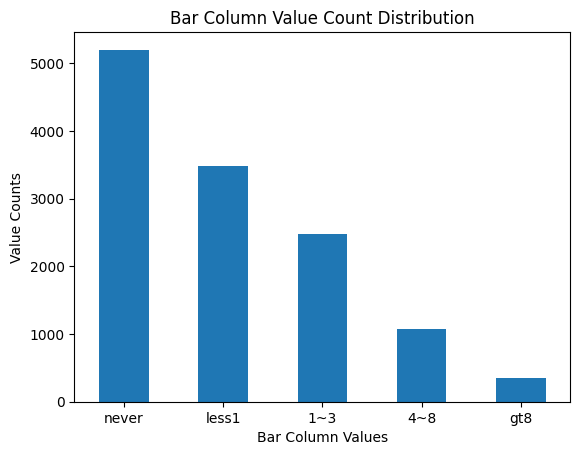

In [224]:
# For the other columns with missing data, see what the most common value is
# Start with "Bar" column
data["Bar"].value_counts().plot(kind = "bar")
plt.xticks(rotation = 360)
plt.xlabel("Bar Column Values")
plt.ylabel("Value Counts")
plt.title("Bar Column Value Count Distribution")
plt.show()

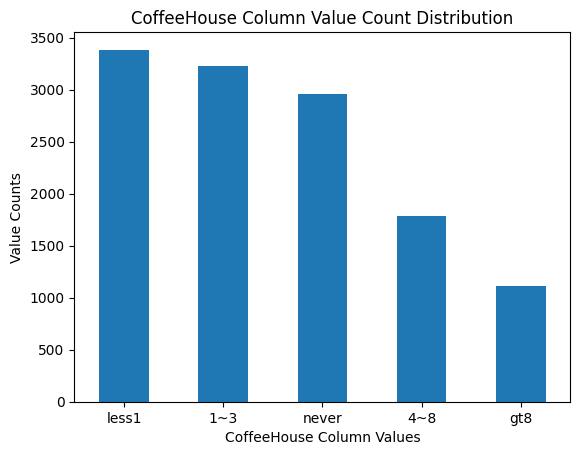

In [225]:
# "CoffeeHouse" column values distribution
data["CoffeeHouse"].value_counts().plot(kind = "bar")
plt.xticks(rotation = 360)
plt.xlabel("CoffeeHouse Column Values")
plt.ylabel("Value Counts")
plt.title("CoffeeHouse Column Value Count Distribution")
plt.show()

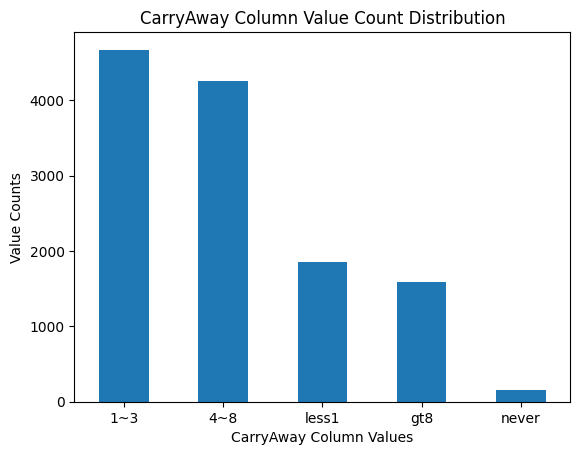

In [226]:
# "CarryAway" column values distribution
data["CarryAway"].value_counts().plot(kind = "bar")
plt.xticks(rotation = 360)
plt.xlabel("CarryAway Column Values")
plt.ylabel("Value Counts")
plt.title("CarryAway Column Value Count Distribution")
plt.show()

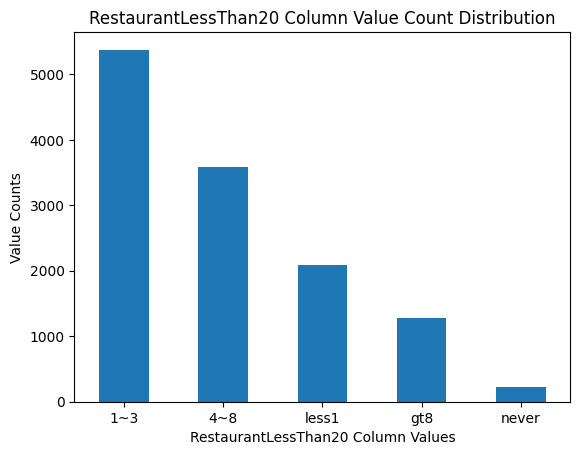

In [227]:
# "RestaurantLessThan20" column values distribution
data["RestaurantLessThan20"].value_counts().plot(kind = "bar")
plt.xticks(rotation = 360)
plt.xlabel("RestaurantLessThan20 Column Values")
plt.ylabel("Value Counts")
plt.title("RestaurantLessThan20 Column Value Count Distribution")
plt.show()

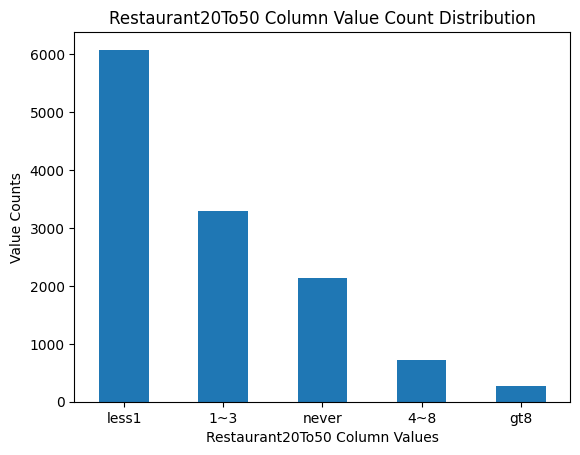

In [228]:
# "Restaurant20To50" column values distribution
data["Restaurant20To50"].value_counts().plot(kind = "bar")
plt.xticks(rotation = 360)
plt.xlabel("Restaurant20To50 Column Values")
plt.ylabel("Value Counts")
plt.title("Restaurant20To50 Column Value Count Distribution")
plt.show()

In [229]:
# For remaining columns with missing values, replace with most common value
cols = ["Bar", "CoffeeHouse", "CarryAway", "RestaurantLessThan20", "Restaurant20To50"]
for col in cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# Should show no more missing values
data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

In [230]:
# Further corrections to dataframe structure

# Fix capitalization across columns so it matches
data.columns = data.columns.str.title()

# Change mispelled column "passanger" to "passenger" and "Y" to "Coupon" and match underscore usage
data = data.rename(columns={
    "Passanger": "Passenger",
    "Y": "Coupon_Accepted",
    "Maritalstatus": "Marital_Status",
    "Coffeehouse": "Coffee_House",
    "Carryaway": "Carry_Away",
    "Restaurantlessthan20": "Restaurant_LessThan20",
    "Restaurant20to50": "Restaurant_20to50",
    "Tocoupon_Geq15Min": "ToCoupon_GEQ15min",
    "Tocoupon_Geq25Min": "ToCoupon_GEQ25min"
})

data.columns

Index(['Destination', 'Passenger', 'Weather', 'Temperature', 'Time', 'Coupon',
       'Expiration', 'Gender', 'Age', 'Marital_Status', 'Has_Children',
       'Education', 'Occupation', 'Income', 'Bar', 'Coffee_House',
       'Carry_Away', 'Restaurant_LessThan20', 'Restaurant20To50',
       'Tocoupon_Geq5Min', 'ToCoupon_GEQ15min', 'ToCoupon_GEQ25min',
       'Direction_Same', 'Direction_Opp', 'Coupon_Accepted'],
      dtype='object')

4. What proportion of the total observations chose to accept the coupon?



In [231]:
# We can calculate this by finding the mean and multiplying by 100 to get the percentage
percent_accept_coupon = data["Coupon_Accepted"].mean() * 100
print(percent_accept_coupon)

56.84326710816777


The proportion of the total observations that chose to accept the coupon is 56.84%. This distribution is further visualized via the next figure which shows the percentage of people that accepted vs rejected the coupon.

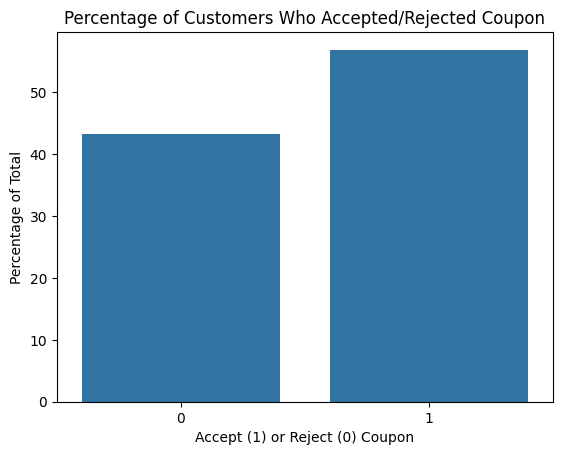

In [232]:
sns.countplot(data = data, x = "Coupon_Accepted", stat = "percent")
plt.title("Percentage of Customers Who Accepted/Rejected Coupon")
plt.xlabel("Accept (1) or Reject (0) Coupon")
plt.ylabel("Percentage of Total")
plt.show()

5. Use a bar plot to visualize the `coupon` column.

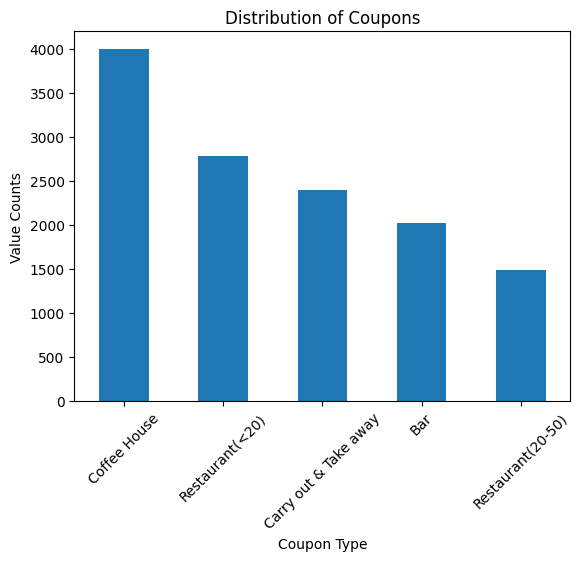

In [233]:
data["Coupon"].value_counts().plot(kind = "bar")
plt.title("Distribution of Coupons")
plt.xticks(rotation = 45)
plt.xlabel("Coupon Type")
plt.ylabel("Value Counts")
plt.show()

The above bar plot shows the distribution of the coupon column across the different coupon types. In order to analyze further, a secondary plot was created below to depict the distribution across coupon types color-coded by the Coupon_Accepted column.

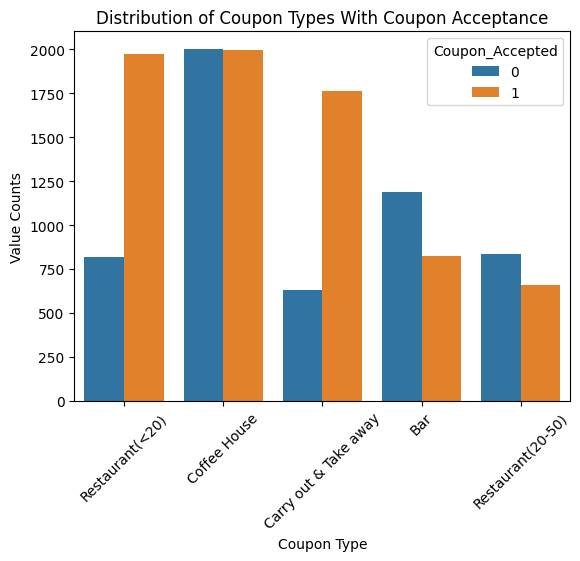

In [234]:
sns.countplot(data = data, x = "Coupon", hue = "Coupon_Accepted")
plt.xticks(rotation = 45)
plt.title("Distribution of Coupon Types With Coupon Acceptance")
plt.xlabel("Coupon Type")
plt.ylabel("Value Counts")
plt.show()

To make the ratios of coupon accepted versus rejected for each coupon type even clearer, a third plot is created below with the stat argument set to percent to better show the ratio of coupon accepted versus rejected across catergories.

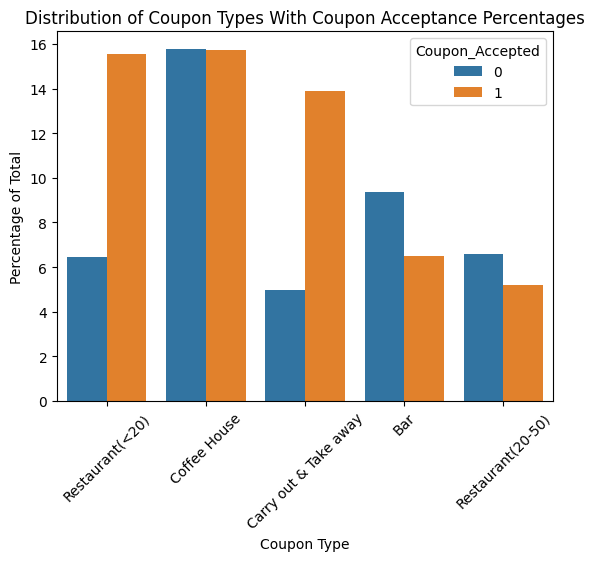

In [235]:
sns.countplot(data = data, x = "Coupon", hue = "Coupon_Accepted", stat = "percent")
plt.xticks(rotation = 45)
plt.title("Distribution of Coupon Types With Coupon Acceptance Percentages")
plt.xlabel("Coupon Type")
plt.ylabel("Percentage of Total")
plt.show()

From these graphs, we can see that across the categories, those who received a coupon for less expensive restaurants or a coupon for carry-out tended to accept the coupon rather than reject it, those who received a coffee house coupon had a close 50/50 split but with coupon rejection slightly higher, while bar and more expensive restaurant coupons resulted in more coupon rejections than acceptances.

6. Use a histogram to visualize the temperature column.

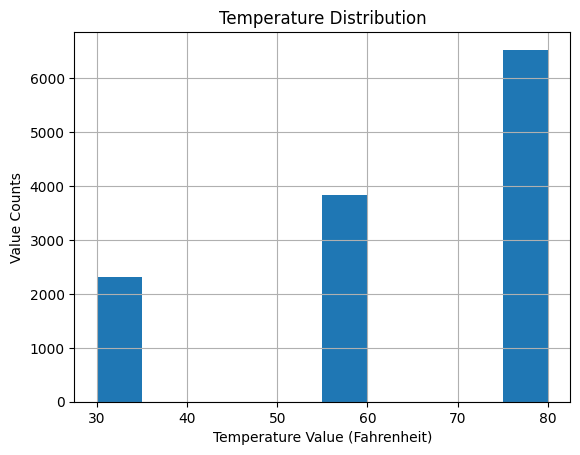

In [236]:
data["Temperature"].hist()
plt.title("Temperature Distribution")
plt.xlabel("Temperature Value (Fahrenheit)")
plt.ylabel("Value Counts")
plt.show()

The histogram above shows the distribution across the three temperature values. In order to analyze further, a secondary plot was created below to depict the distribution across temperature values color-coded by the Coupon_Accepted column.

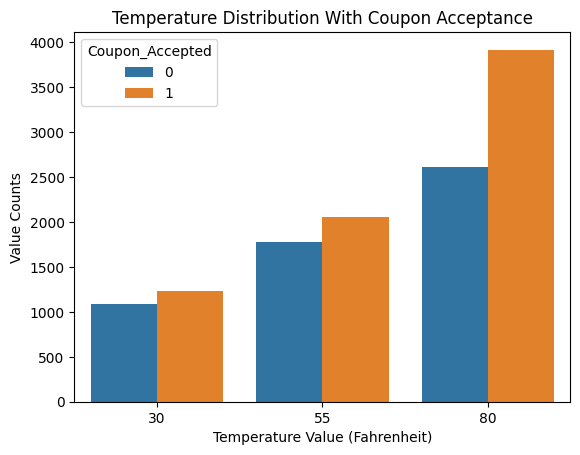

In [237]:
sns.countplot(data = data, x = "Temperature", hue = "Coupon_Accepted")
plt.title("Temperature Distribution With Coupon Acceptance")
plt.xlabel("Temperature Value (Fahrenheit)")
plt.ylabel("Value Counts")
plt.show()

To make the ratios of coupon accepted versus rejected for each temperature value even clearer, a third plot is created below with the stat argument set to percent to better show the ratio of coupon accepted versus rejected across temperatures.

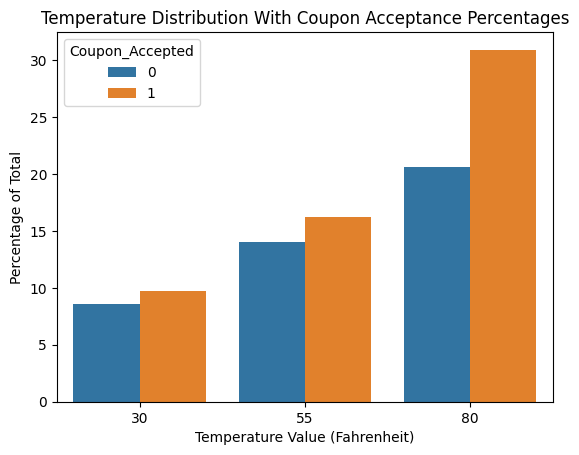

In [238]:
sns.countplot(data = data, x = "Temperature", hue = "Coupon_Accepted", stat = "percent")
plt.title("Temperature Distribution With Coupon Acceptance Percentages")
plt.xlabel("Temperature Value (Fahrenheit)")
plt.ylabel("Percentage of Total")
plt.show()

We can see that across the three temperature values, a greater percentage of customers accepted the coupon rather than rejected it, with the greatest difference present for the temperature of 80 degrees Fahrenheit.

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [239]:
bar_coupons = data[data["Coupon"] == "Bar"]

2. What proportion of bar coupons were accepted?


In [240]:
# We can calculate this by finding the mean and multiplying by 100 to get the percentage
percent_accept_bar = bar_coupons["Coupon_Accepted"].mean() * 100
print(percent_accept_bar)

41.00148735746158


The proportion of bar coupons that were accepted is 41%. This distribution is further visualized via the next figure which shows the percentage of people that accepted vs rejected the bar coupon.

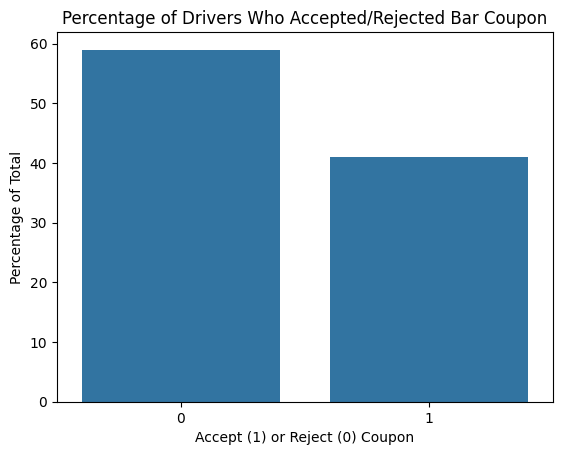

In [242]:
sns.countplot(data = bar_coupons, x = "Coupon_Accepted", stat = "percent")
plt.title("Percentage of Drivers Who Accepted/Rejected Bar Coupon")
plt.xlabel("Accept (1) or Reject (0) Coupon")
plt.ylabel("Percentage of Total")
plt.show()

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [243]:
# Calculate the acceptance rate for those going to a bar 3 or fewer times per month
leq3 = bar_coupons[bar_coupons["Bar"].isin(["less1", "1~3"])]
leq3_percent_accept = leq3["Coupon_Accepted"].mean() * 100
print("Bar Coupon Acceptance Percent for 3 or fewer visits/month:", leq3_percent_accept)

# Calculate the acceptance rate for those going to a bar more than 3 times per month
gt3 = bar_coupons[bar_coupons["Bar"].isin(["4~8", "gt8"])]
gt3_percent_accept = gt3["Coupon_Accepted"].mean() * 100
print("Bar Coupon Acceptance Percent for more than 3 visits/month:", gt3_percent_accept)

# Compare the two values
if leq3_percent_accept > gt3_percent_accept:
    print("Drivers who visit a bar 3 times or fewer per month accept the bar coupons more.")
elif gt3_percent_accept > leq3_percent_accept:
    print("Drivers who visit a bar more than 3 times per month accept the bar coupons more.")
else:
    print("Both groups accept the bar coupons equally.")

Bar Coupon Acceptance Percent for 3 or fewer visits/month: 52.74043433298863
Bar Coupon Acceptance Percent for more than 3 visits/month: 76.88442211055276
Drivers who visit a bar more than 3 times per month accept the bar coupons more.


We find that the bar coupon acceptance rate for drivers who visit a bar 3 or less times per month is 52.74%, while the acceptance rate for those who visit a bar more than 3 times per month is 76.88%. Thus, drivers who visit a bar more than 3 times per month tend to accept the bar coupons more than those whoe visit 3 or less times per month. We can further visualize these acceptance rates through the plots in the two figures seen below.

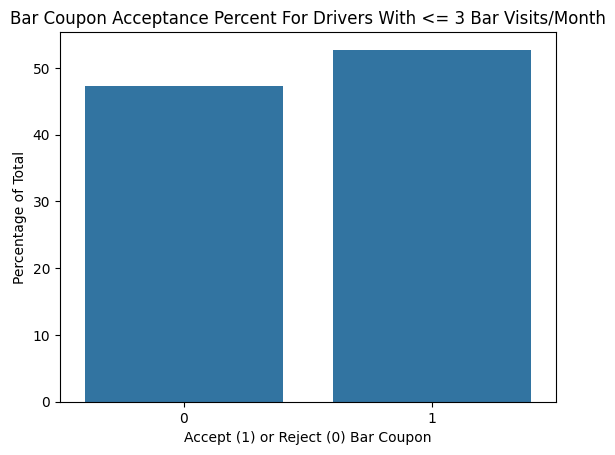

In [244]:
sns.countplot(data = leq3, x = "Coupon_Accepted", stat = "percent")
plt.title("Bar Coupon Acceptance Percent For Drivers With <= 3 Bar Visits/Month")
plt.xlabel("Accept (1) or Reject (0) Bar Coupon")
plt.ylabel("Percentage of Total")
plt.show()

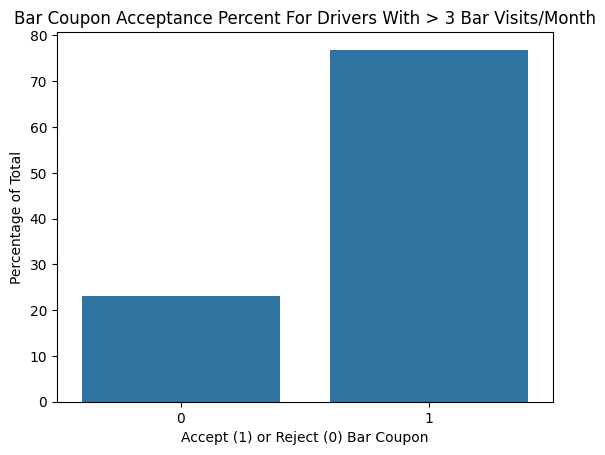

In [245]:
sns.countplot(data = gt3, x = "Coupon_Accepted", stat = "percent")
plt.title("Bar Coupon Acceptance Percent For Drivers With > 3 Bar Visits/Month")
plt.xlabel("Accept (1) or Reject (0) Bar Coupon")
plt.ylabel("Percentage of Total")
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [246]:
# First calculate the acceptance rate for drivers who go to a bar > 1 visit/month and are > 25 yrs old 
gt1_over25 = bar_coupons[
    (bar_coupons["Bar"].isin(["1~3", "4~8", "gt8"])) & 
    (bar_coupons["Age"] != "21") &
    (bar_coupons["Age"] != 'below21')
]

gt1_over25_percent_accept = gt1_over25["Coupon_Accepted"].mean() * 100
print("Bar Coupon Acceptance Percent for drivers over 25 with more than 1 visits/month:", gt1_over25_percent_accept)

# Next calculate the acceptance rate for everyone else
others_q4 = bar_coupons.drop(gt1_over25.index)
others_q4_percent_accept = others_q4["Coupon_Accepted"].mean() * 100
print("Bar Coupon Acceptance Percent for all other drivers:", others_q4_percent_accept)

# Compare the two values
if gt1_over25_percent_accept > others_q4_percent_accept:
    print("Drivers who visit a bar more than once a month and are over 25 accept the bar coupons more.")
elif others_q4_percent_accept > gt1_over25_percent_accept:
    print("Other drivers accept the bar coupons more.")
else:
    print("Both groups accept the bar coupons equally.")

Bar Coupon Acceptance Percent for drivers over 25 with more than 1 visits/month: 69.52380952380952
Bar Coupon Acceptance Percent for all other drivers: 33.500313087038194
Drivers who visit a bar more than once a month and are over 25 accept the bar coupons more.


We find that the bar coupon acceptance rate for drivers over 25 who visit a bar 1 or more times per month is 69.52% while the acceptance rate for other drivers is 33.5%. Thus, drivers who are over 25 and visit a bar at least 1 time per month tend to accept the bar coupons more than all other drivers. We can further visualize these acceptance rates through the plots in the two figures below.

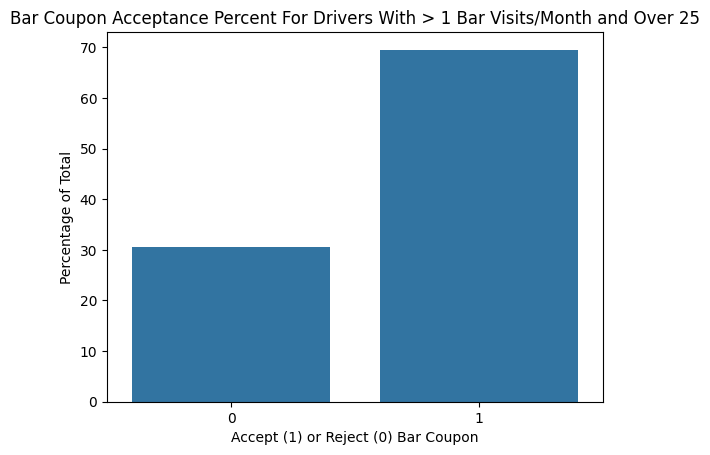

In [247]:
sns.countplot(data = gt1_over25, x = "Coupon_Accepted", stat = "percent")
plt.title("Bar Coupon Acceptance Percent For Drivers With > 1 Bar Visits/Month and Over 25")
plt.xlabel("Accept (1) or Reject (0) Bar Coupon")
plt.ylabel("Percentage of Total")
plt.show()

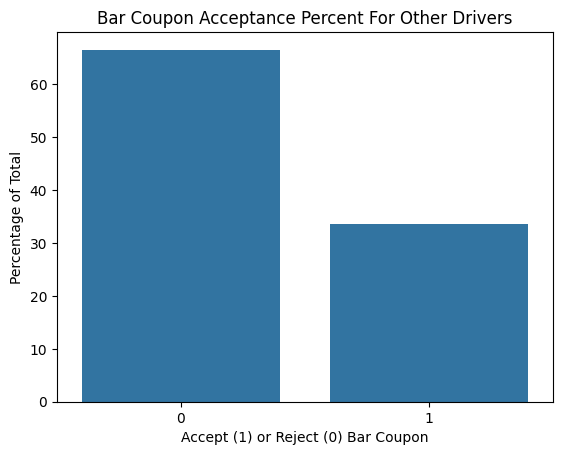

In [248]:
sns.countplot(data = others_q4, x = "Coupon_Accepted", stat = "percent")
plt.title("Bar Coupon Acceptance Percent For Other Drivers")
plt.xlabel("Accept (1) or Reject (0) Bar Coupon")
plt.ylabel("Percentage of Total")
plt.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [249]:
# First calculate the acceptance rate for drivers who go to a bar > 1 visit/month and had non-kid passengers, and occupation isn't FFF
gt1_nokid_notFFF = bar_coupons[
    (bar_coupons["Bar"].isin(["1~3", "4~8", "gt8"])) & 
    (bar_coupons["Passenger"] != "Kid(s)") &
    (bar_coupons["Passenger"] != "Alone") &
    (bar_coupons["Occupation"] != 'Farming Fishing & Forestry')
]

gt1_nokid_notFFF_percent_accept = gt1_nokid_notFFF["Coupon_Accepted"].mean() * 100
print("Bar Coupon Acceptance Percent for drivers with more than 1 visits/month, \n non-child passengers, and not in Farming/Fishing/Forestry:",
      gt1_nokid_notFFF_percent_accept)

# Next calculate the acceptance rate for everyone else
others_q5 = bar_coupons.drop(gt1_nokid_notFFF.index)
others_q5_percent_accept = others_q5["Coupon_Accepted"].mean() * 100
print("Bar Coupon Acceptance Percent for all other drivers:", others_q5_percent_accept)

# Compare the two values
if gt1_nokid_notFFF_percent_accept > others_q5_percent_accept:
    print("Drivers who visit a bar more than once a month with non-kid passengers who have occupations \n" \
        "other than farming, fishing, or forestry accept the bar coupons more.")
elif others_q5_percent_accept > gt1_nokid_notFFF_percent_accept:
    print("Other drivers accept the bar coupons more.")
else:
    print("Both groups accept the bar coupons equally.")

Bar Coupon Acceptance Percent for drivers with more than 1 visits/month, 
 non-child passengers, and not in Farming/Fishing/Forestry: 71.7948717948718
Bar Coupon Acceptance Percent for all other drivers: 37.70581778265642
Drivers who visit a bar more than once a month with non-kid passengers who have occupations 
other than farming, fishing, or forestry accept the bar coupons more.


We find that the bar coupon acceptance rate for drivers who visit a bar 1 or more times per month, had non-kid passengers, and were not in Farming/Fishing/Forestry is 71.79%, while the acceptance rate for other drivers is 37.71%. Thus, drivers who visit a bar at least 1 time per month, had non-kid passengers, and have occupations other than farming, fishing, or forestry accept the bar coupons more than all other drivers. We can further visualize these acceptance rates through the plots in the two figures below.

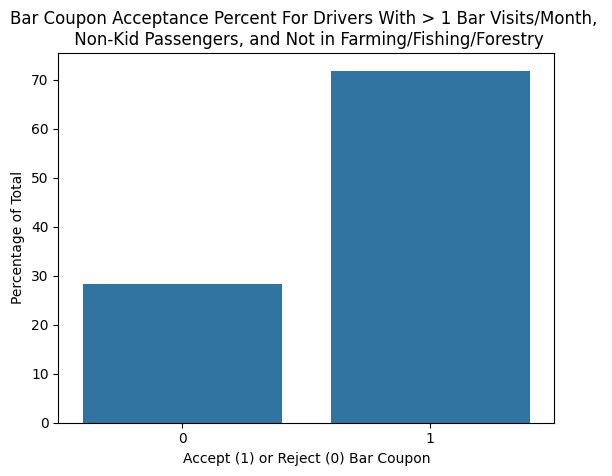

In [250]:
sns.countplot(data = gt1_nokid_notFFF, x = "Coupon_Accepted", stat = "percent")
plt.title("Bar Coupon Acceptance Percent For Drivers With > 1 Bar Visits/Month, " \
    "\n Non-Kid Passengers, and Not in Farming/Fishing/Forestry")
plt.xlabel("Accept (1) or Reject (0) Bar Coupon")
plt.ylabel("Percentage of Total")
plt.show()

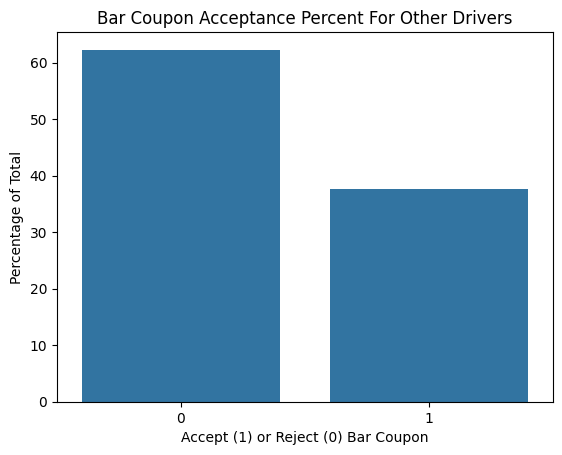

In [251]:
sns.countplot(data = others_q5, x = "Coupon_Accepted", stat = "percent")
plt.title("Bar Coupon Acceptance Percent For Other Drivers")
plt.xlabel("Accept (1) or Reject (0) Bar Coupon")
plt.ylabel("Percentage of Total")
plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [252]:
# First calculate the acceptance rate for drivers who go to a bar > 1 visit/month, had non-kid passengers, and were not widowed
gt1_nokid_notwidow = bar_coupons[
    (bar_coupons["Bar"].isin(["1~3", "4~8", "gt8"])) & 
    (bar_coupons["Passenger"] != "Kid(s)") &
    (bar_coupons["Passenger"] != "Alone") &
    (bar_coupons["Marital_Status"] != 'Widowed')
]

gt1_nokid_notwidow_percent_accept = gt1_nokid_notwidow["Coupon_Accepted"].mean() * 100
print("Bar Coupon Acceptance Percent for drivers with more than 1 visits/month, \n non-child passengers, and not Widowed:",
      gt1_nokid_notwidow_percent_accept)

# Next calculate the acceptance rate for drivers who go to a bar > 1 visit/month and are under 30
gt1_under30 = bar_coupons[
    (bar_coupons["Bar"].isin(["1~3", "4~8", "gt8"])) &
    (bar_coupons["Age"].isin(["below21", "21", "26"]))
]

gt1_under30_percent_accept = gt1_under30["Coupon_Accepted"].mean() * 100
print("Bar Coupon Acceptance Percent for drivers under 30 with more than 1 visits/month:", gt1_under30_percent_accept)

# Next calculate the acceptance rate for drivers who go to cheap restaurants > 4 visit/month, and income < 50K
gt4cheap_lt50k = bar_coupons[
    (bar_coupons['Restaurant_LessThan20'].isin(['4~8','gt8'])) &
    (bar_coupons['Income'].isin([
        'Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999'
    ]))
]

gt4cheap_lt50k_percent_accept = gt4cheap_lt50k["Coupon_Accepted"].mean() * 100
print("Bar Coupon Acceptance Percent for drivers making less than 50K \n " \
    "with 4 or more cheap restaurant visit/month:", gt4cheap_lt50k_percent_accept)

# Compare the three values
if (gt1_nokid_notwidow_percent_accept > gt1_under30_percent_accept) & (gt1_nokid_notwidow_percent_accept > gt4cheap_lt50k_percent_accept):
    print("Drivers who visit a bar more than once a month with non-kid passengers and aren't widowed accept the bar coupons more.")
elif (gt1_under30_percent_accept > gt1_nokid_notwidow_percent_accept) & (gt1_under30_percent_accept > gt4cheap_lt50k_percent_accept):
    print("Drivers under 30 who visit a bar more than once a month accept the bar coupons more.")
elif (gt4cheap_lt50k_percent_accept > gt1_nokid_notwidow_percent_accept) & (gt4cheap_lt50k_percent_accept > gt1_under30_percent_accept):
    print("Drivers make less than 50K and go to cheap restaurants more than 4 times a month accept the bar coupons more.")
else:
    print("The three groups accept the bar coupons equally.")

Bar Coupon Acceptance Percent for drivers with more than 1 visits/month, 
 non-child passengers, and not Widowed: 71.7948717948718
Bar Coupon Acceptance Percent for drivers under 30 with more than 1 visits/month: 72.17391304347827
Bar Coupon Acceptance Percent for drivers making less than 50K 
 with 4 or more cheap restaurant visit/month: 45.348837209302324
Drivers under 30 who visit a bar more than once a month accept the bar coupons more.


We find that the bar coupon acceptance rate for drivers who visit a bar 1 or more times per month, had non-kid passengers, and are not widowed is 71.79%, while the acceptance rate for drivers under 30 who visit a bar 1 or more times per month is 72.17%, and the acceptance rate for drivers with income less than 50K who visit cheap restaurants 4 or more times per month is 45.35%. Thus, drivers under 30 who visit a bar more than once a month accept the bar coupons more than the two other groups of drivers. We can further visualize these acceptance rates through the plots in the two figures below.

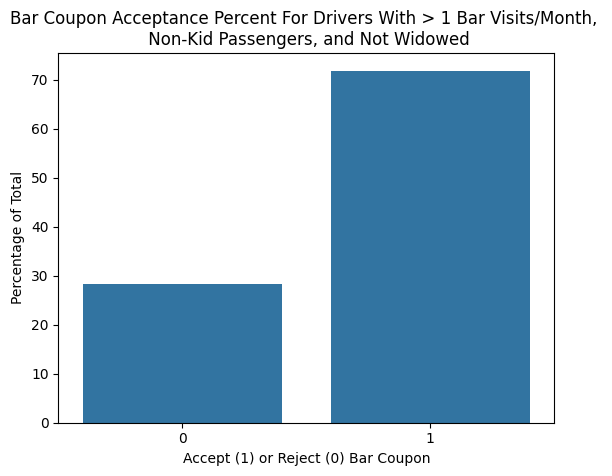

In [253]:
sns.countplot(data = gt1_nokid_notwidow, x = "Coupon_Accepted", stat = "percent")
plt.title("Bar Coupon Acceptance Percent For Drivers With > 1 Bar Visits/Month, " \
    "\n Non-Kid Passengers, and Not Widowed")
plt.xlabel("Accept (1) or Reject (0) Bar Coupon")
plt.ylabel("Percentage of Total")
plt.show()

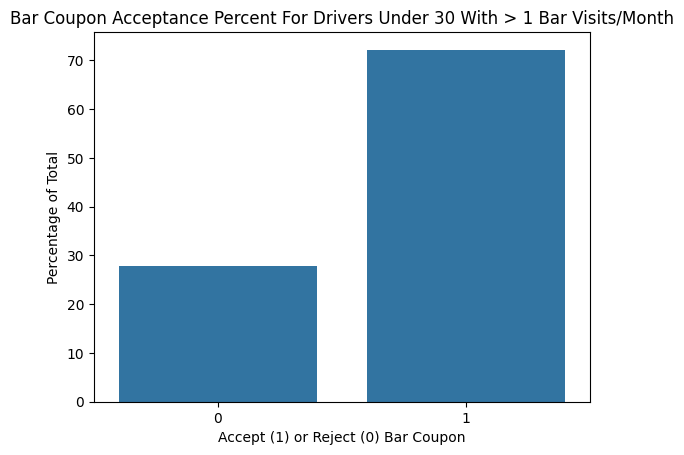

In [254]:
sns.countplot(data = gt1_under30, x = "Coupon_Accepted", stat = "percent")
plt.title("Bar Coupon Acceptance Percent For Drivers Under 30 With > 1 Bar Visits/Month")
plt.xlabel("Accept (1) or Reject (0) Bar Coupon")
plt.ylabel("Percentage of Total")
plt.show()

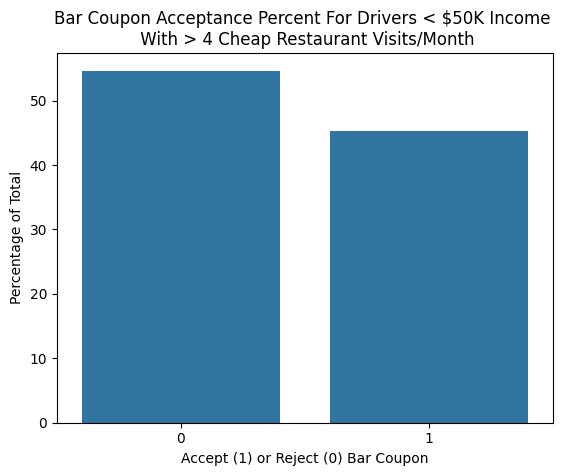

In [255]:
sns.countplot(data = gt4cheap_lt50k, x = "Coupon_Accepted", stat = "percent")
plt.title("Bar Coupon Acceptance Percent For Drivers < $50K Income " \
    "\n With > 4 Cheap Restaurant Visits/Month")
plt.xlabel("Accept (1) or Reject (0) Bar Coupon")
plt.ylabel("Percentage of Total")
plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

**Hypothesis**: Based on these observations, we can hypothesize that drivers who accept the bar coupons tend to visit bars more frequently per month than drivers who reject the bar coupons. For example, we can see a large gap in the acceptance percentage in question 3 between drivers who go to bars 3 or less times per month versus drivers who go to bars more than 3 times per month. Overall, we can still see that drivers who visit a bar more than once per month tend to accept the bar coupons rather than reject them. This behavior suggests that drivers who already have a habit of going to the bar at least once a month tend to be more receptive to accepting coupons for bars.

From the other questions, we can also see that drivers who have passengers that are not children, and drivers on the younger side (less than 30) also tend to accept the bar coupons rather than reject them. This behavior suggests that younger drivers and drivers who are in the company of other people (non-children) are also more likely to accept bar coupons as going to the bar can then be a group activity to do together, and younger drivers tend to see going to bars as a fun activity to do moreso than older drivers.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

1. Create DataFrame for Carry out & Take away coupons

In [256]:
# Create a DataFrame that contains just the Carry out & Take away coupons
takeout_coupons = data[data["Coupon"] == "Carry out & Take away"]
takeout_coupons.head()

,Destination,Passenger,Weather,Temperature,Time,Coupon,Expiration,Gender,Age,Marital_Status,...,Coffee_House,Carry_Away,Restaurant_LessThan20,Restaurant20To50,Tocoupon_Geq5Min,ToCoupon_GEQ15min,ToCoupon_GEQ25min,Direction_Same,Direction_Opp,Coupon_Accepted
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
6,No Urgent Place,Friend(s),Sunny,55,2PM,Carry out & Take away,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
8,No Urgent Place,Kid(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
19,Work,Alone,Sunny,80,7AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,1,0,1
25,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0


2. Calculate what proportion of carry out coupons were accepted

In [257]:
# Calculate what proportion of carry out coupons were accepted
percent_accept_takeout = takeout_coupons["Coupon_Accepted"].mean() * 100
print(percent_accept_takeout)

73.54784788967822


The proportion of take out coupons that were accepted is 73.55%. We can further visualize this distribution via the next figure which shows the percentage of people that accepted vs rejected the take out coupon.

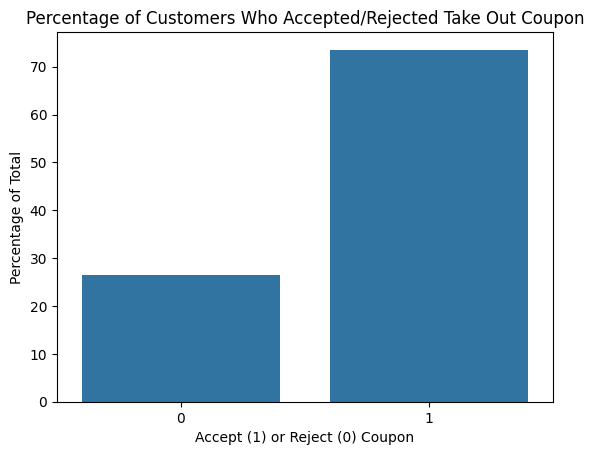

In [258]:
sns.countplot(data = takeout_coupons, x = "Coupon_Accepted", stat = "percent")
plt.title("Percentage of Customers Who Accepted/Rejected Take Out Coupon")
plt.xlabel("Accept (1) or Reject (0) Coupon")
plt.ylabel("Percentage of Total")
plt.show()

We can see from this figure and the calculations that the majority of drivers offered a take out coupon tend to accept the coupon, with an acceptance percentage of 73.55%.

3. We will now investigate various features in an effort to figure out which factors have the greatest influence on take out coupon acceptance. Following each feature analysis will be a brief observation about what we can see from the given calculations/figure.

A: Take Out Coupon Acceptance by Age

Age
21         74.074074
26         73.191489
31         70.558376
36         74.698795
41         71.770335
46         72.800000
50plus     77.456647
below21    72.807018
Name: Coupon_Accepted, dtype: float64


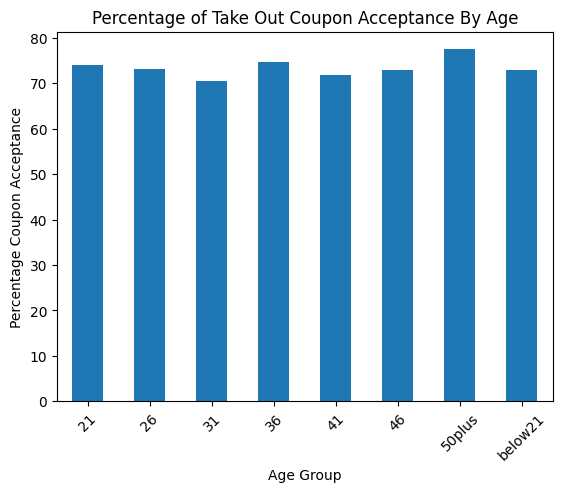

In [259]:
# Compare acceptance by driver age
percent_by_age = takeout_coupons.groupby("Age")["Coupon_Accepted"].mean() * 100
print(percent_by_age)

percent_by_age.plot(kind = "bar")
plt.title("Percentage of Take Out Coupon Acceptance By Age")
plt.xticks(rotation = 45)
plt.xlabel("Age Group")
plt.ylabel("Percentage Coupon Acceptance")
plt.show()

From the above calculations and figure, we can see that across the age groups the take out coupon acceptance rate remains similar at around 70%. The age group with the highest acceptance percentage is the 50+ age group.

B: Take Out Coupon Acceptance by Time of Day

Time
10AM    70.212766
10PM    75.921909
2PM     86.697248
6PM     82.528736
7AM     65.485564
Name: Coupon_Accepted, dtype: float64


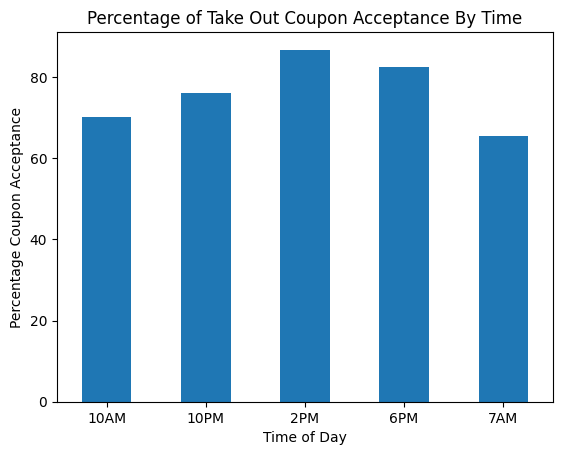

In [260]:
# Compare acceptance by time of day
percent_by_time = takeout_coupons.groupby("Time")["Coupon_Accepted"].mean() * 100
print(percent_by_time)

percent_by_time.plot(kind = "bar")
plt.title("Percentage of Take Out Coupon Acceptance By Time")
plt.xticks(rotation = 360)
plt.xlabel("Time of Day")
plt.ylabel("Percentage Coupon Acceptance")
plt.show()

From the above calculations and figure, we can see that across the time of day groupings there is some variation in the take out coupon acceptance rate. We can see that the time with the highest acceptance percentage is 2 PM, with 6 PM being a close second.

C: Take Out Coupon Acceptance by Passenger Type

Passenger
Alone        72.740214
Friend(s)    75.778078
Kid(s)       70.394737
Partner      73.195876
Name: Coupon_Accepted, dtype: float64


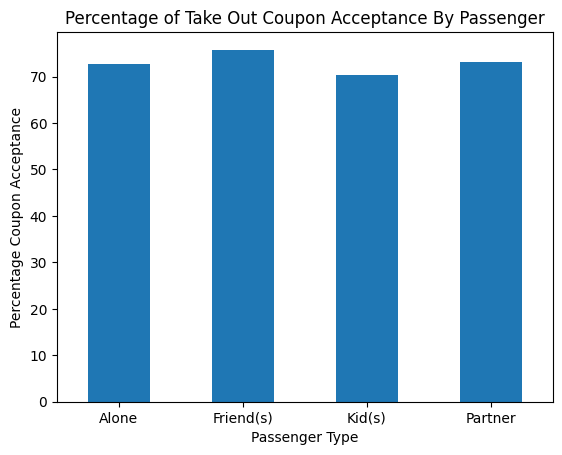

In [261]:
# Compare acceptance by passenger type
percent_by_passenger = takeout_coupons.groupby("Passenger")["Coupon_Accepted"].mean() * 100
print(percent_by_passenger)

percent_by_passenger.plot(kind = "bar")
plt.title("Percentage of Take Out Coupon Acceptance By Passenger")
plt.xticks(rotation = 360)
plt.xlabel("Passenger Type")
plt.ylabel("Percentage Coupon Acceptance")
plt.show()

From the above calculations and figure, we can see that across the passenger types the take out coupon acceptance rate remains similar at around 70%. The passenger type with the highest acceptance percentage is Friend(s).

D: Take Out Coupon Acceptance by Temperature

Temperature
30    75.632490
55    71.875000
80    72.983114
Name: Coupon_Accepted, dtype: float64


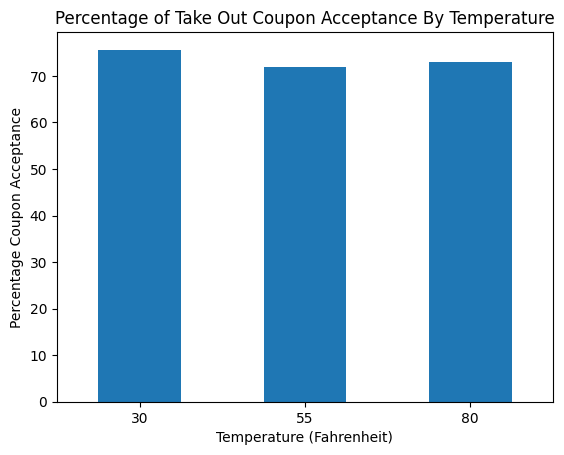

In [262]:
# Compare acceptance by temperature
percent_by_temperature = takeout_coupons.groupby("Temperature")["Coupon_Accepted"].mean() * 100
print(percent_by_temperature)

percent_by_temperature.plot(kind = "bar")
plt.title("Percentage of Take Out Coupon Acceptance By Temperature")
plt.xticks(rotation = 360)
plt.xlabel("Temperature (Fahrenheit)")
plt.ylabel("Percentage Coupon Acceptance")
plt.show()

From the above calculations and figure, we can see that across the temperature values the take out coupon acceptance rate remains similar at around 70%. The temperature value with the highest acceptance percentage is 30 degrees Fahrenheit.

E: Take Out Coupon Acceptance by Number of Times He/She Buys Takeaway Food per Month

Carry_Away
1~3      73.927765
4~8      75.365854
gt8      73.841060
less1    67.988669
never    75.000000
Name: Coupon_Accepted, dtype: float64


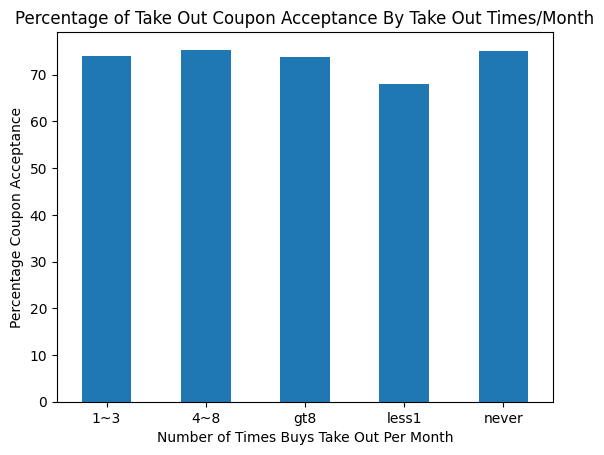

In [ ]:
# Compare acceptance by number of times he/she buys takeaway food
percent_by_timetakeout = takeout_coupons.groupby("Carry_Away")["Coupon_Accepted"].mean() * 100
print(percent_by_timetakeout)

percent_by_timetakeout.plot(kind = "bar")
plt.title("Percentage of Take Out Coupon Acceptance By Take Out Times/Month")
plt.xticks(rotation = 360)
plt.xlabel("Number of Times Buy Take Out Per Month")
plt.ylabel("Percentage Coupon Acceptance")
plt.show()

From the above calculations and figure, we can see that across the groupings for the number of times the driver buys take out per month the take out coupon acceptance rate remains similar at around 70-75%. The grouping with the highest acceptance percentage is when buying takeout 4 to 8 times per month.

F: Take Out Coupon Acceptance by Destination

Destination
Home               78.866769
No Urgent Place    76.278119
Work               65.485564
Name: Coupon_Accepted, dtype: float64


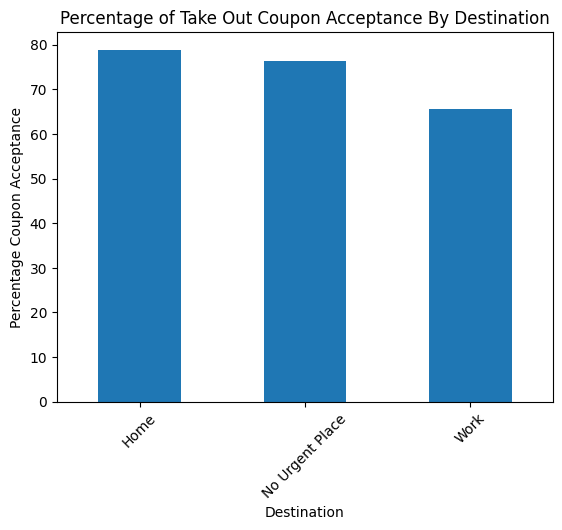

In [264]:
# Compare acceptance by destination
percent_by_destination = takeout_coupons.groupby("Destination")["Coupon_Accepted"].mean() * 100
print(percent_by_destination)

percent_by_destination.plot(kind = "bar")
plt.title("Percentage of Take Out Coupon Acceptance By Destination")
plt.xticks(rotation = 45)
plt.xlabel("Destination")
plt.ylabel("Percentage Coupon Acceptance")
plt.show()

From the above calculations and figure, we can see that across the destination groupings there is some variation in the take out coupon acceptance rate. We can see that the destination with the highest acceptance percentage is Home, with No Urgent Place being a close second.

G: Take Out Coupon Acceptance by if Venue in Same Direction as Destination

Direction_Same
0    75.1250
1    70.3657
Name: Coupon_Accepted, dtype: float64


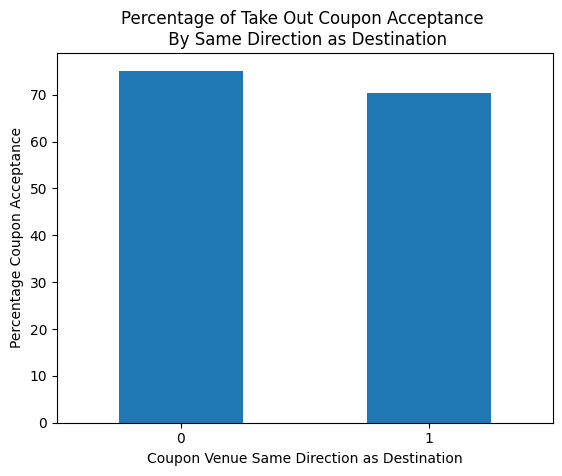

In [ ]:
# Compare acceptance by if it's in the same direction
percent_by_samedir = takeout_coupons.groupby("Direction_Same")["Coupon_Accepted"].mean() * 100
print(percent_by_samedir)

percent_by_samedir.plot(kind = "bar")
plt.title("Percentage of Take Out Coupon Acceptance \n By Same Direction as Destination")
plt.xticks(rotation = 360)
plt.xlabel("Coupon Venue Is (1) or Is Not (0) in Same Direction as Destination")
plt.ylabel("Percentage Coupon Acceptance")
plt.show()

From the above calculations and figure, we can see that the acceptance percentage for coupons whose venue is in the opposite direction of the driver's destination is actually higher than the acceptance percentage for coupons whose venus is in the same direction as the driver's destination. 

H: Take Out Coupon Acceptance by Driver is Going Home AND Venue is in Same Direction as Destination

In [266]:
# Calculate the acceptance rate for those going home and the coupon venue is in the same direction as the destination
home_venue_same = takeout_coupons[
    (takeout_coupons["Destination"] == "Home") &
    (takeout_coupons["Direction_Same"] == 1)
]

home_venue_same_percent_accept = home_venue_same["Coupon_Accepted"].mean() * 100
print("Take Out Coupon Acceptance Percent for drivers going home where venue is in the same direction:", home_venue_same_percent_accept)

Take Out Coupon Acceptance Percent for drivers going home where venue is in the same direction: 82.01892744479495


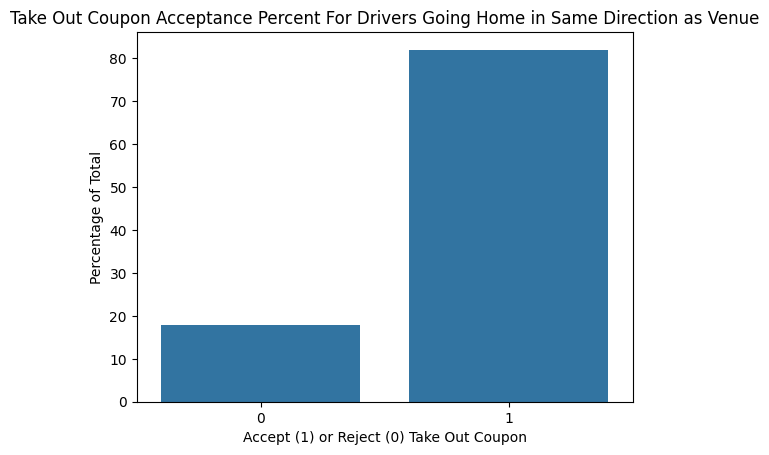

In [267]:
sns.countplot(data = home_venue_same, x = "Coupon_Accepted", stat = "percent")
plt.title("Take Out Coupon Acceptance Percent For Drivers Going Home in Same Direction as Venue")
plt.xlabel("Accept (1) or Reject (0) Take Out Coupon")
plt.ylabel("Percentage of Total")
plt.show()

From the above calculations and figure, we can see that drivers who are going home where the coupon venue is in the same direction as their home are much more likely to accept the take out coupons than reject the coupon.

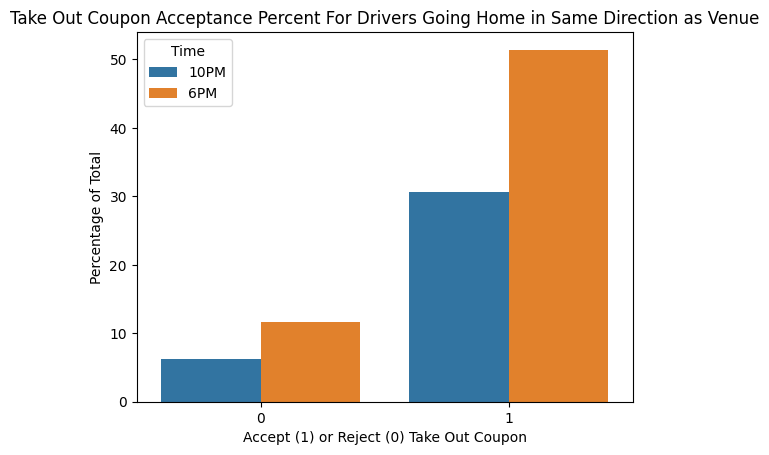

In [268]:
sns.countplot(data = home_venue_same, x = "Coupon_Accepted", hue = "Time", stat = "percent")
plt.title("Take Out Coupon Acceptance Percent For Drivers Going Home in Same Direction as Venue")
plt.xlabel("Accept (1) or Reject (0) Take Out Coupon")
plt.ylabel("Percentage of Total")
plt.show()

Further analysis was done with a secondary figure to see how time of day affects the distribution for drivers who are going home where the venue is in the same direction as their home. We can see that there is a greater acceptance rate when the time is 6 PM versus 10 PM.

I: Take Out Coupon Acceptance by Driver is Going Somewhere Not Urgent AND Time is 2 PM

In [269]:
# Calculate the acceptance rate for those going somewhere not urgent and the time is 2 PM
not_urgent_2PM = takeout_coupons[
    (takeout_coupons["Destination"] == "No Urgent Place") &
    (takeout_coupons["Time"] == "2PM")
]

not_urgent_2PM_percent_accept = not_urgent_2PM["Coupon_Accepted"].mean() * 100
print("Take Out Coupon Acceptance Percent for drivers going somewhere not urgent at 2 PM:", not_urgent_2PM_percent_accept)

Take Out Coupon Acceptance Percent for drivers going somewhere not urgent at 2 PM: 86.69724770642202


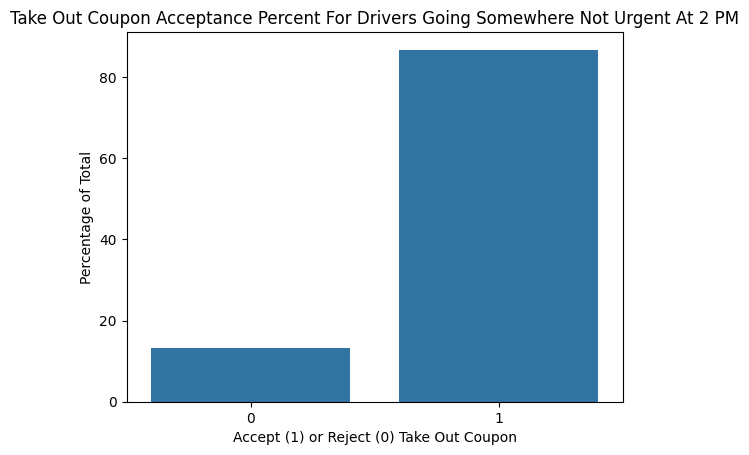

In [270]:
sns.countplot(data = not_urgent_2PM, x = "Coupon_Accepted", stat = "percent")
plt.title("Take Out Coupon Acceptance Percent For Drivers Going Somewhere Not Urgent At 2 PM")
plt.xlabel("Accept (1) or Reject (0) Take Out Coupon")
plt.ylabel("Percentage of Total")
plt.show()

From the above calculations and figure, we can see that drivers who are going somewhere not urgent around 2 PM are much more likely to accept the take out coupons than reject the coupon.

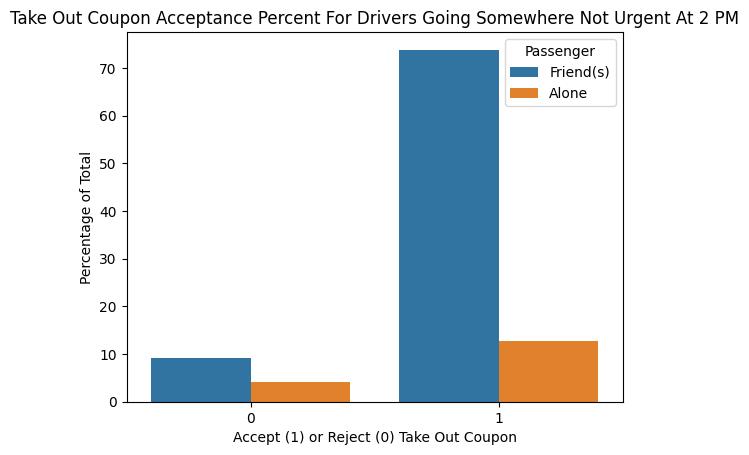

In [273]:
sns.countplot(data = not_urgent_2PM, x = "Coupon_Accepted", hue = "Passenger", stat = "percent")
plt.title("Take Out Coupon Acceptance Percent For Drivers Going Somewhere Not Urgent At 2 PM")
plt.xlabel("Accept (1) or Reject (0) Take Out Coupon")
plt.ylabel("Percentage of Total")
plt.show()

Further analysis was done with a secondary figure to see how passenger status affects the distribution for drivers who are going somewhere not urgent at 2 PM. We can see that there is a greater acceptance rate when the driver has friends as passengers versus being alone.

4. **Take Out Coupon Findings + Next Steps/Recommendations**

From this analysis of the take out coupon acceptance rates, we can see that the demographics with the greatest acceptance rates are drivers who are going home where the coupon venue is in the same direction, and drivers who are going somewhere not urgent at 2 PM. 

We can also see that for drivers going home with the venue in the same direction accept coupons more often around 6 PM than 10 PM, and drivers who are going somewhere not urgent at 2 PM have a higher acceptance rate when they are with friends than when they are alone.

We can hypothesize that drivers going home with the venue in the same direction at 6 PM are more likely to accept take out coupons because they are heading home from work and it is easier to pick up dinner than cook at home. Have the venue be in the same direction also means the driver doesn't have to detour too much and spend more time to use the coupon.

We can also hypothesize that drivers going nowhere urgent at 2 PM with friends are more likely to accept take out coupons becuase picking up take out for lunch then becomes part of their group outing as another activity to do together.

For the next steps to take advantage of these findings, more coupons for take out can be sent out around 2 PM and 6 PM, which were found to be the times with the highest acceptance rates. During weekdays at 6 PM, around when people are getting off work, take out coupons whose venues are in the same direction as the driver's destination should be prioritized and sent out in higher volume. During weekends at 2 PM, when it's more likely that people are driving with their friends, is another peak time when more take out coupons should be distributed.

